# LAPORAN PRAKTIKUM <br> Pengolahan Citra dan Visi Komputer (PCVK)

**Nama** : Mufliha Hafsyah Shahieza <br>
**NIM** : 244107020147 <br>
**Kelas** : TI-3G

---

## Modul 3 – Operasi Citra Sederhana

In [23]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Mufliha Hafsyah Shahieza'
NIM = '244107020147'

N = int(NIM[-3:])
PARAM = {
    'b'     : (N % 61) + 20,
    'a'     : round(1.0 + (N % 9) / 10, 1),
    'c'     : (N % 20) + 30,
    'gamma' : round(0.4 + (N % 6) * 0.25, 2),
    'bit'   : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA   :', NAMA)
print('NIM    :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU  :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN  :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA   : Mufliha Hafsyah Shahieza
NIM    : 244107020147 | N = 147
b      : 45
a      : 1.3
c      : 37
gamma  : 1.15
bit    : 5
WAKTU  : 2026-09-18 17:24:40 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN  : df6c624e10fa550f


### **E1. Operasi Citra Sederhana**

1. **Akses folder images pada Google Drive:**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. **Melakukan transformasi linier brightness dengan memasukkan nilai konstanta tertentu
dan menghasilkan warna**

**Transformasi Linier Brightness**<br>
Formula: *g(x,y) = f(x,y)+b*<br>
* *g(x,y)* adalah nilai pixel setelah transformasi
* *f(x,y)* adalah nilai piksel asli
* *b* adalah nilai brightness

 Mengubah tingkat kecerahan citra 
----------------------------------
Masukkan nilai kecerahan: 45


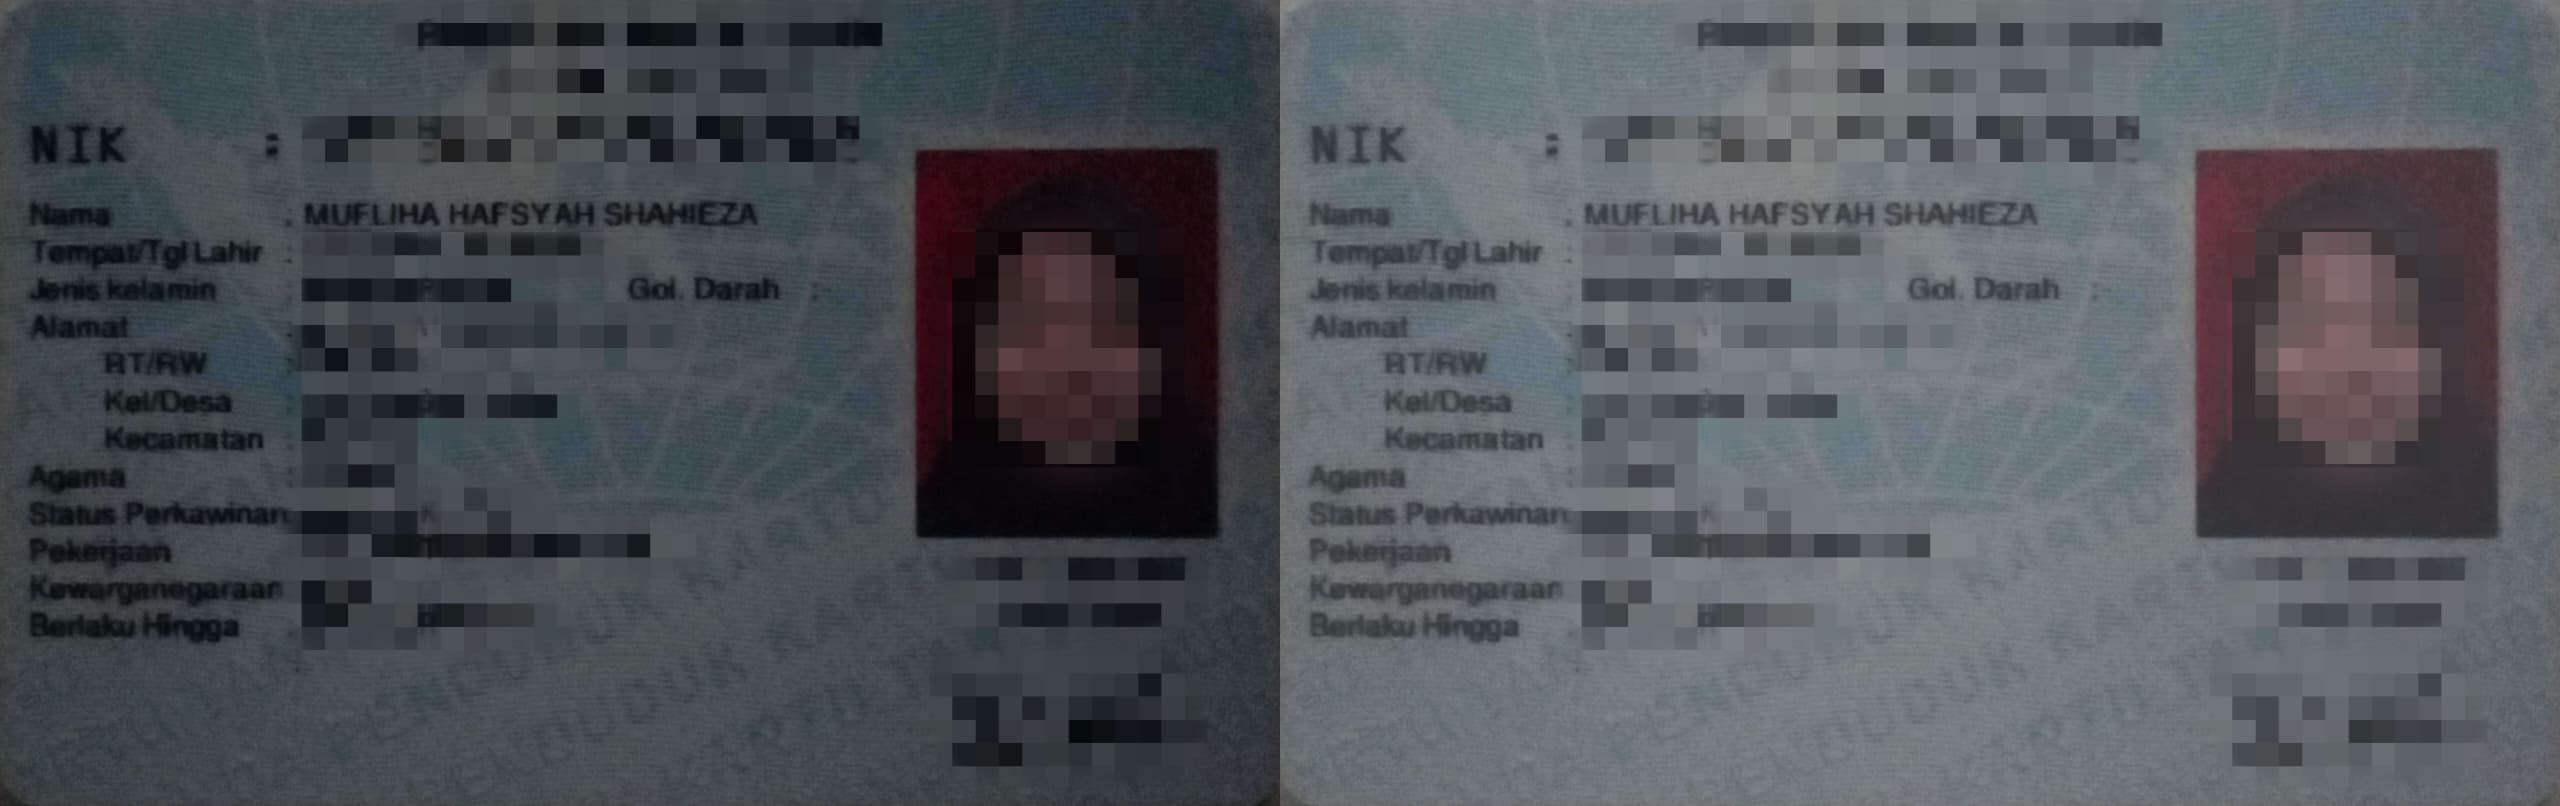

In [42]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print(' Mengubah tingkat kecerahan citra ')
print('----------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1a.jpeg')
brightness_image = np.zeros(original.shape, original.dtype)

#akses per piksel
#np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
for y in range(original.shape[0]):
  for x in range(original.shape[1]):
    for c in range(original.shape[2]):
      brightness_image[y,x,c] = np.clip(original[y,x,c] + brightness, 0, 255)

#cara simple tanpa for loop
#brightness_img = cv.convertScaleAbs(original, beta=brightness)

final_frame = cv.hconcat((original, brightness_image))
cv2_imshow(final_frame)

### **TUGAS PRAKTIKUM**

1. **Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan
berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontras.**



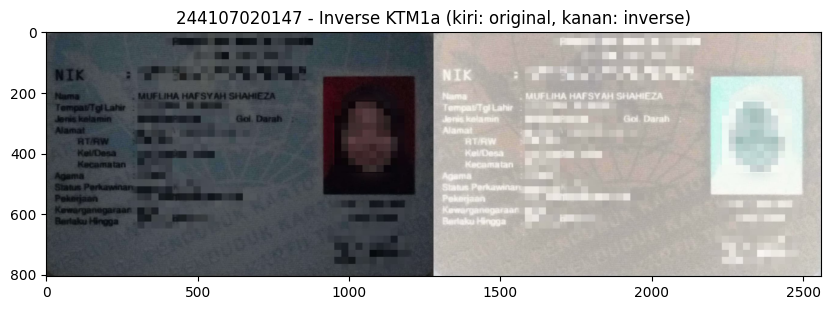

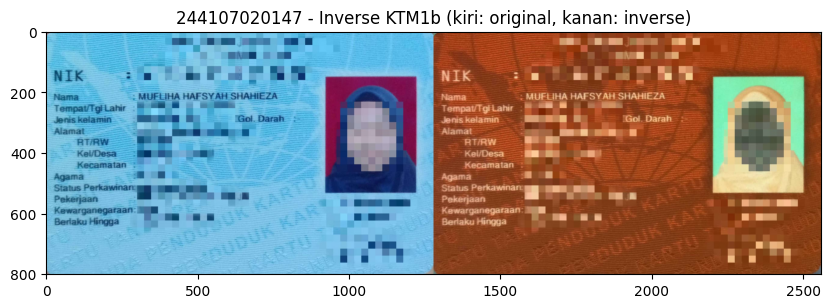

In [32]:
KTP1a = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1a.jpeg')
KTP1b = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1b.jpeg')

inv_KTP1a = 255 - KTP1a
inv_KTP1b = 255 - KTP1b

# KTP1a: original vs inverse
final_frame_a = cv.hconcat((KTP1a, inv_KTP1a))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final_frame_a, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Inverse KTM1a (kiri: original, kanan: inverse)')
plt.show()

# KTP1b: original vs inverse
final_frame_b = cv.hconcat((KTP1b, inv_KTP1b))
plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final_frame_b, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Inverse KTM1b (kiri: original, kanan: inverse)')
plt.show()

Jelaskan mengapa citra negatif dari KTM1a (ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap kontras. <br>
**Jawaban:** <br>
* KTM1a diambil di ruangan gelap, sehingga nilai piksel aslinnya berkumpul di angka rendah (mendekati 0). Saat di-inverse nilai-nilai piksel rendah yang berdekatan tersebut sama-sama berubah menjadi nilai tinggi (mendekati 255) dan saling berdekatan pula. Akibatnya, citra hasil negatif didominasi warna terang yang seragam, sehingga tampak pucat dan berkabut.
* Sebaliknya, KTM1b diambil dengan pencahayaan lampu ruangan yang cukup, sehingga rentang nilai piksel aslinya sudah bervariasi lebar. Saat di-inverse, variasi lebar ini tetap terjaga (piksel gelap dan terang hanya saling bertukar posisi nilai, bukan menyempit ke satu rentang), sehingga detail dan kontras pada citra negatifnya tetap terlihat jelas.

Jadi, dapat diambil kesimpulan bahwa kualitas kontras citra negatif sangat bergantung pada range nilai piksel citra asli. Semakin sempit rentang nilai piksel asli, semakin pucat/berkabut hasil inverse-nya. Semakin lebar rentang nilai piksel asli, semakin kontras pula hasil inverse-nya.

2. **Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda
(PARAM['a']) pada KTM1a.jpg**

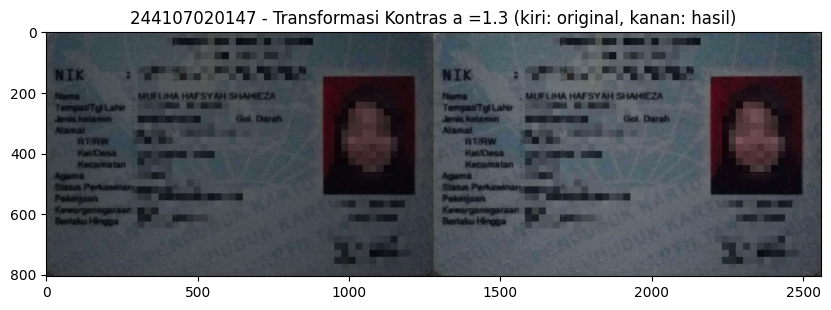

In [34]:
KTP1a = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1a.jpeg')

a = PARAM['a']
kontras = np.clip(KTP1a.astype(np.float32) * a, 0, 255).astype(np.uint8)

final_frame_kontras = cv.hconcat((KTP1a, kontras))

plt.figure(figsize=(10,5))
plt.imshow(cv.cvtColor(final_frame_kontras, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Transformasi Kontras a =' + str(a) + ' (kiri: original, kanan: hasil)')
plt.show()

3. **Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitung
dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness
memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan
metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan
bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.**

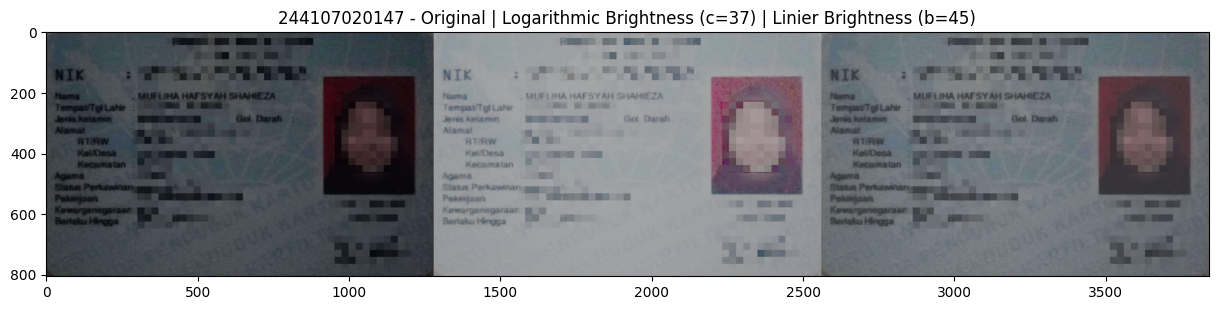

In [38]:
from os import link
KTP1a = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1a.jpeg')

c = PARAM['c']
b = PARAM['b']

# Logarithmic Brightness
log_KTP1a = c * np.log(1 + KTP1a.astype(np.float32))
log_KTP1a = np.clip(log_KTP1a, 0, 255).astype(np.uint8)

# Linier Brightness
lin_KTP1a = np.clip(KTP1a.astype(np.int16) + b, 0, 255).astype(np.uint8)

final_frame = cv.hconcat((KTP1a, log_KTP1a, lin_KTP1a))

plt.figure(figsize=(15,5))
plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Original | Logarithmic Brightness (c=' + str(c) + ') | Linier Brightness (b=' + str(b) + ')')
plt.show()


**Jawaban:** <br>
* Berdasarkan hasil eksperimen pada KTM1a.jpg, ternyata metode Linier Brightness (b=45) menghasilkan citra yang lebih terbaca dibanding Logarithmic Brightness (c=37), berbeda dengan teori umum yang biasanya menyebutkan Log Brightness lebih unggul untuk citra gelap.

* Hal ini terjadi karena nilai c=37 dengan basis logaritma natural (np.log) menghasilkan rentang keluaran maksimum hanya sekitar 205 (37 × ln(256) ≈ 205,2), sehingga seluruh piksel "dipadatkan" ke rentang sempit dan justru terlihat pudar, meskipun secara teknis tidak ada piksel yang mengalami clipping ke 255.

* Sebaliknya, Linier Brightness menambahkan nilai konstan +45 secara merata sehingga proporsi kontras relatif antar piksel pada citra asli tetap terjaga.

* Pada kedua citra hasil transformasi, tidak ditemukan bagian yang benar-benar putih (nilai piksel 255). Pada Logarithmic Brightness hal ini wajar terjadi karena nilai output maksimumnya secara matematis memang tidak bisa mencapai 255, dibuktikan dari perhitungan (37 × ln(256) ≈ 205), sehingga sebesar apapun nilai piksel aslinya, hasilnya tidak akan pernah mentok di 255. <br>Sedangkan pada Linier Brightness, tidak ada bagian yang di clipping artinya nilai piksel paling terang pada citra asli KTM1a masih berada di bawah 210 (255−45 = 210), sehingga penambahan konstanta +45 belum sampai membuat piksel manapun melewati batas 255.




4. **Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan
metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.**<br><br>
Rumus:
* Averaging: (R + G + B) / 3
* Lightness: (max(R,G,B) + min(R,G,B)) / 2
* Luminance: 0,299R + 0,587G + 0,114B

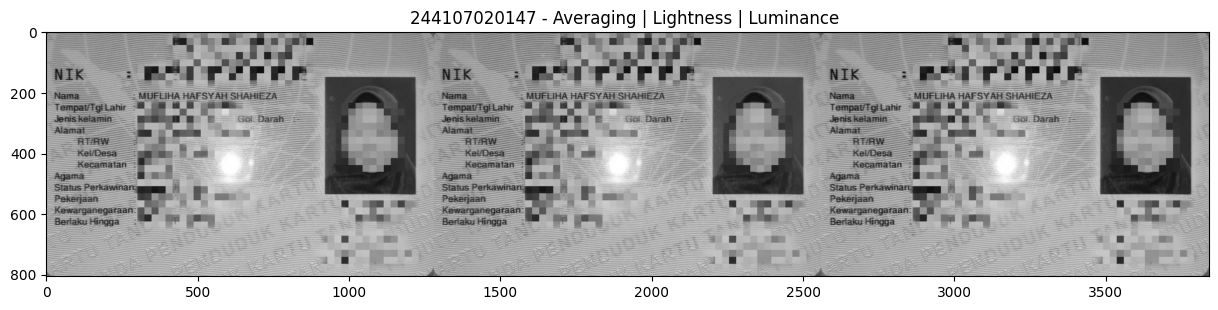

      Metode   Rata-rata  Simpangan Baku
0  Averaging  149.567586       46.193283
1  Lightness  146.679814       44.384975
2  Luminance  147.573296       47.415587


In [43]:
KTP1c = cv.imread('/content/drive/MyDrive/PCVK2026/KTP1c.jpeg')
KTP1c_f = KTP1c.astype(np.float32)

B = KTP1c_f[:,:,0]
G = KTP1c_f[:,:,1]
R = KTP1c_f[:,:,2]

# Averaging
gray_avg = ((R + G + B) / 3).astype(np.uint8)

# Lightness
gray_light = ((np.maximum(np.maximum(R,G),B) + np.minimum(np.minimum(R,G),B)) / 2).astype(np.uint8)

# Luminance (Rec. 601, sama seperti cv.COLOR_BGR2GRAY)
gray_lum = (0.299*R + 0.587*G + 0.114*B).astype(np.uint8)

final_frame = cv.hconcat((gray_avg, gray_light, gray_lum))

plt.figure(figsize=(15,5))
plt.imshow(final_frame, cmap='gray')
plt.title(NIM + ' - Averaging | Lightness | Luminance ')
plt.show()

# Hitung rata-rata dan simpangan baku
data = {
    'Metode': ['Averaging', 'Lightness', 'Luminance'],
    'Rata-rata': [np.mean(gray_avg), np.mean(gray_light), np.mean(gray_lum)],
    'Simpangan Baku': [np.std(gray_avg), np.std(gray_light), np.std(gray_lum)]
}
df = pd.DataFrame(data)
print(df)

5. Tampilkan satu warna tertentu pada citra dan ubah bagian lainnya menjadi grayscale.
Gunakan OBJ1.jpg, yaitu foto benda milik Anda sendiri dengan satu warna dominan.
Sebutkan rentang nilai HSV yang Anda pakai sebagai batas warna, lalu tunjukkan
pengaruhnya apabila rentang tersebut diperlebar dan dipersempit.

6. Gamma Correction pada Citra Pribadi
Nilai gamma diminta dari pengguna melalui kode di bawah ini. Lanjutkan kode tersebut
sesuai rumus pada Ulasan Teori, kemudian terapkan pada KTM1a.jpg. Mulailah dari nilai
gamma hasil hitung dari NIM Anda, lalu cari secara bertahap nilai gamma yang membuat
NIM dan nama pada kartu paling terbaca. Tampilkan minimal lima nilai gamma yang dicoba beserta hasilnya, sebutkan nilai gamma terbaik pilihan Anda, dan jelaskan
mengapa nilai terbaik setiap mahasiswa berbeda meskipun jenis objeknya sama.

7. Buat Simulasi Image Depth pada Citra Pribadi <br>
Percobaan ini digunakan sebagai simulasi dari proses kuantisasi citra. Pada kuantisasi
citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit).
Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga
255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0
(000 0000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit.
Jika 7bit, maka jumlah warnanya adalah 2^7 = 128, dst.<br><br>
Kuantisasi KTM1b.jpg pada kedalaman 1 sampai 7 bit dan tampilkan seluruh hasilnya.
Tentukan pada kedalaman berapa nama dan NIM pada kartu Anda masih terbaca,